<a href="https://colab.research.google.com/github/Aishwarya-J05/Pytorch/blob/main/pytorch_classsification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Classification with PyTorch

# 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples=1000

# Create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"first 5 samples of x:\n {X[:5]}")
print(f"first 5 samples of y:\n {y[:5]}")

first 5 samples of x:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y:
 [1 1 1 1 0]


In [5]:
# make dataframe of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


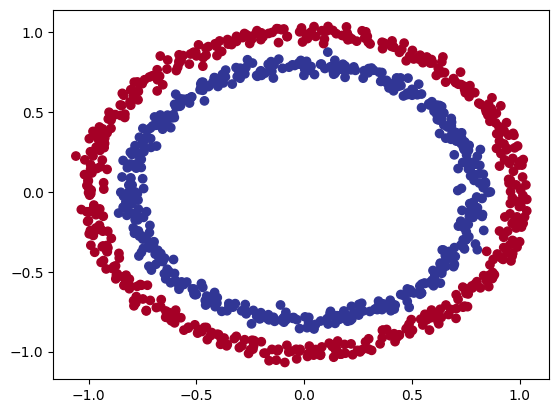

In [6]:
# visualize
import matplotlib.pyplot as plt

plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

## 1.1 Check imput and output shapes

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [9]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [10]:
# view the first example of features and labels
X_sample=X[0]
y_sample=y[0]

print(f"values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
shapes for one sample of X: (2,) and the same for y: ()


## 1.2 Turn data into tensors and create train and test splits

In [11]:
import torch

In [12]:
torch.__version__

'2.10.0+cu128'

In [13]:
# turn data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [14]:
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [15]:
X.dtype,y.dtype,type(X)

(torch.float32, torch.float32, torch.Tensor)

In [16]:
# split the data into traning and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42)


In [17]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# 2.  Building a model

Let's build a model to classify red and blue dots.

In [18]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [20]:
# 1. construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
  # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
    super().__init__()

    self.layer_1=nn.Linear(in_features=2, out_features=5)
    self.layer_2=nn.Linear(in_features=5, out_features=1)

  # 3. define a forward() method that outlines the forward pass
  def forward(self,x):
    return self.layer_2(self.layer_1(x)) # x -> layer 1 -> layer 2 -> output

# 4 Instantiate an instance of our model class and send it to the target device
model_0 =CircleModelV0().to(device)

model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
device

'cuda'

In [22]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [23]:
# let's rpelicate the model above using nn.Sequential
model_0=nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4284,  0.2881],
                      [-0.3446,  0.6107],
                      [ 0.4607, -0.7051],
                      [ 0.3985,  0.6578],
                      [ 0.3048,  0.4104]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.1442,  0.0386, -0.5772,  0.2100, -0.2501], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.4320,  0.0722,  0.3640, -0.3257,  0.4051]], device='cuda:0')),
             ('1.bias', tensor([-0.3952], device='cuda:0'))])

In [25]:
# Make predictions
with torch.inference_mode():
  untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape of predictions: {untrained_preds.shape}")
print(f"Lenght if test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 test labels: \n{y_test[:10]}")

Length of predictions: 200, Shape of predictions: torch.Size([200, 1])
Lenght if test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.],
        [-1.]], device='cuda:0')

First 10 test labels: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

In [27]:
# setup loss function
# loss_fn=nn.BCELoss()
loss_fn = nn.BCEWithLogitsLoss()

optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.1)

In [28]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4284,  0.2881],
                      [-0.3446,  0.6107],
                      [ 0.4607, -0.7051],
                      [ 0.3985,  0.6578],
                      [ 0.3048,  0.4104]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.1442,  0.0386, -0.5772,  0.2100, -0.2501], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.4320,  0.0722,  0.3640, -0.3257,  0.4051]], device='cuda:0')),
             ('1.bias', tensor([-0.3952], device='cuda:0'))])

In [29]:
# calculate accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,torch.round(y_pred)).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

## 3. Training a model

In [30]:
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.7846],
        [-0.8414],
        [-0.6330],
        [-0.8276],
        [-0.6282]], device='cuda:0')

In [31]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [32]:
# use the sigmoid activation function on the model
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3133],
        [0.3012],
        [0.3468],
        [0.3041],
        [0.3479]], device='cuda:0')

In [33]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

In [34]:
y_preds=torch.round( y_pred_probs)

y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [35]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Building training and testing loop

In [36]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


epochs=100

X_train, y_train=X_train.to(device), y_train.to(device)
X_test, y_test=X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  y_logits=model_0(X_train).squeeze()
  y_pred =torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,
               y_train)
  acc=accuracy_fn(y_true=y_train,
                  y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    test_loss=loss_fn(test_logits,
                      y_test)
    test_acc=accuracy_fn(y_true=y_test,
                         y_pred=test_pred)

  # print out whats happening
  if epoch % 10 ==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.75623, Acc: 50.00% | Test Loss: 0.74803, Test Acc: 50.00%
Epoch: 10 | Loss: 0.71714, Acc: 50.00% | Test Loss: 0.71324, Test Acc: 50.00%
Epoch: 20 | Loss: 0.70295, Acc: 50.00% | Test Loss: 0.70103, Test Acc: 50.00%
Epoch: 30 | Loss: 0.69755, Acc: 50.00% | Test Loss: 0.69665, Test Acc: 50.00%
Epoch: 40 | Loss: 0.69537, Acc: 45.25% | Test Loss: 0.69505, Test Acc: 43.00%
Epoch: 50 | Loss: 0.69441, Acc: 47.25% | Test Loss: 0.69444, Test Acc: 44.00%
Epoch: 60 | Loss: 0.69394, Acc: 48.25% | Test Loss: 0.69420, Test Acc: 45.00%
Epoch: 70 | Loss: 0.69367, Acc: 49.12% | Test Loss: 0.69410, Test Acc: 45.50%
Epoch: 80 | Loss: 0.69350, Acc: 49.62% | Test Loss: 0.69406, Test Acc: 46.00%
Epoch: 90 | Loss: 0.69338, Acc: 49.12% | Test Loss: 0.69405, Test Acc: 49.50%


## 4. Let's make some predictions and evaluate the model

In [40]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Download helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary


helper_functions.py already exists, skipping download


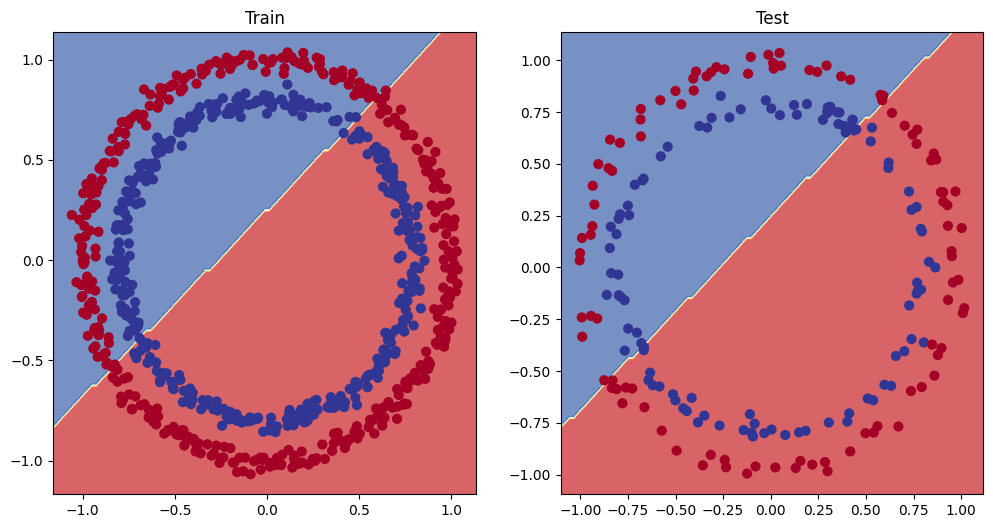

In [41]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)
